### Модель для прогнозирования качества сна

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
data = pd.read_csv('student_sleep_patterns.csv')
data

,Student_ID,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Sleep_Quality,Weekday_Sleep_Start,Weekend_Sleep_Start,Weekday_Sleep_End,Weekend_Sleep_End
0,1,24,Other,2nd Year,7.7,7.9,3.4,2,37,10,14.16,4.05,7.41,7.06
1,2,21,Male,1st Year,6.3,6.0,1.9,5,74,2,8.73,7.10,8.21,10.21
2,3,22,Male,4th Year,5.1,6.7,3.9,5,53,5,20.00,20.47,6.88,10.92
3,4,24,Other,4th Year,6.3,8.6,2.8,4,55,9,19.82,4.08,6.69,9.42
4,5,20,Male,4th Year,4.7,2.7,2.7,0,85,3,20.98,6.12,8.98,9.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,24,Male,2nd Year,5.1,9.3,1.9,4,110,4,17.42,8.43,6.93,10.78
496,497,20,Male,2nd Year,8.9,7.7,3.5,3,40,4,1.22,15.54,5.85,7.23
497,498,21,Male,3rd Year,5.7,6.4,3.9,1,68,10,9.94,2.25,5.46,10.72
498,499,18,Female,2nd Year,4.9,0.5,3.5,0,12,2,19.10,15.49,8.35,7.20


In [11]:
y_feature = ['Sleep_Quality']
y = data[y_feature]
y

,Sleep_Quality
0,10
1,2
2,5
3,9
4,3
...,...
495,4
496,4
497,10
498,2


In [12]:
x_features = ['Age', 'Gender', 'University_Year', 'Sleep_Duration', 'Study_Hours', 'Screen_Time', 'Caffeine_Intake', 'Physical_Activity',
             'Weekday_Sleep_Start', 'Weekend_Sleep_Start', 'Weekday_Sleep_End', 'Weekend_Sleep_End']
x = data[x_features]
x

,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Weekday_Sleep_Start,Weekend_Sleep_Start,Weekday_Sleep_End,Weekend_Sleep_End
0,24,Other,2nd Year,7.7,7.9,3.4,2,37,14.16,4.05,7.41,7.06
1,21,Male,1st Year,6.3,6.0,1.9,5,74,8.73,7.10,8.21,10.21
2,22,Male,4th Year,5.1,6.7,3.9,5,53,20.00,20.47,6.88,10.92
3,24,Other,4th Year,6.3,8.6,2.8,4,55,19.82,4.08,6.69,9.42
4,20,Male,4th Year,4.7,2.7,2.7,0,85,20.98,6.12,8.98,9.01
...,...,...,...,...,...,...,...,...,...,...,...,...
495,24,Male,2nd Year,5.1,9.3,1.9,4,110,17.42,8.43,6.93,10.78
496,20,Male,2nd Year,8.9,7.7,3.5,3,40,1.22,15.54,5.85,7.23
497,21,Male,3rd Year,5.7,6.4,3.9,1,68,9.94,2.25,5.46,10.72
498,18,Female,2nd Year,4.9,0.5,3.5,0,12,19.10,15.49,8.35,7.20


In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
x['Gender'] = encoder.fit_transform(x['Gender'])
x

<ipython-input-13-045243497680>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Gender'] = encoder.fit_transform(x['Gender'])


,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Weekday_Sleep_Start,Weekend_Sleep_Start,Weekday_Sleep_End,Weekend_Sleep_End
0,24,2,2nd Year,7.7,7.9,3.4,2,37,14.16,4.05,7.41,7.06
1,21,1,1st Year,6.3,6.0,1.9,5,74,8.73,7.10,8.21,10.21
2,22,1,4th Year,5.1,6.7,3.9,5,53,20.00,20.47,6.88,10.92
3,24,2,4th Year,6.3,8.6,2.8,4,55,19.82,4.08,6.69,9.42
4,20,1,4th Year,4.7,2.7,2.7,0,85,20.98,6.12,8.98,9.01
...,...,...,...,...,...,...,...,...,...,...,...,...
495,24,1,2nd Year,5.1,9.3,1.9,4,110,17.42,8.43,6.93,10.78
496,20,1,2nd Year,8.9,7.7,3.5,3,40,1.22,15.54,5.85,7.23
497,21,1,3rd Year,5.7,6.4,3.9,1,68,9.94,2.25,5.46,10.72
498,18,0,2nd Year,4.9,0.5,3.5,0,12,19.10,15.49,8.35,7.20


In [14]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
x['University_Year'] = encoder.fit_transform(x['University_Year'])
x['University_Year'] = x['University_Year']+1
x

<ipython-input-14-6f264723805b>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['University_Year'] = encoder.fit_transform(x['University_Year'])
<ipython-input-14-6f264723805b>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['University_Year'] = x['University_Year']+1


,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Weekday_Sleep_Start,Weekend_Sleep_Start,Weekday_Sleep_End,Weekend_Sleep_End
0,24,2,2,7.7,7.9,3.4,2,37,14.16,4.05,7.41,7.06
1,21,1,1,6.3,6.0,1.9,5,74,8.73,7.10,8.21,10.21
2,22,1,4,5.1,6.7,3.9,5,53,20.00,20.47,6.88,10.92
3,24,2,4,6.3,8.6,2.8,4,55,19.82,4.08,6.69,9.42
4,20,1,4,4.7,2.7,2.7,0,85,20.98,6.12,8.98,9.01
...,...,...,...,...,...,...,...,...,...,...,...,...
495,24,1,2,5.1,9.3,1.9,4,110,17.42,8.43,6.93,10.78
496,20,1,2,8.9,7.7,3.5,3,40,1.22,15.54,5.85,7.23
497,21,1,3,5.7,6.4,3.9,1,68,9.94,2.25,5.46,10.72
498,18,0,2,4.9,0.5,3.5,0,12,19.10,15.49,8.35,7.20


In [17]:
from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()
x1 = x_scaler.fit_transform(x)
x1 = pd.DataFrame(x1, columns=x.columns)
x1

,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Weekday_Sleep_Start,Weekend_Sleep_Start,Weekday_Sleep_End,Weekend_Sleep_End
0,0.857143,1.0,0.333333,0.74,0.655462,0.800000,0.4,0.308333,0.627338,0.100251,0.605528,0.010076
1,0.428571,0.5,0.000000,0.46,0.495798,0.300000,1.0,0.616667,0.366906,0.253133,0.806533,0.803526
2,0.571429,0.5,1.000000,0.22,0.554622,0.966667,1.0,0.441667,0.907434,0.923308,0.472362,0.982368
3,0.857143,1.0,1.000000,0.46,0.714286,0.600000,0.8,0.458333,0.898801,0.101754,0.424623,0.604534
4,0.285714,0.5,1.000000,0.14,0.218487,0.566667,0.0,0.708333,0.954436,0.204010,1.000000,0.501259
...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.857143,0.5,0.333333,0.22,0.773109,0.300000,0.8,0.916667,0.783693,0.319799,0.484925,0.947103
496,0.285714,0.5,0.333333,0.98,0.638655,0.833333,0.6,0.333333,0.006715,0.676190,0.213568,0.052897
497,0.428571,0.5,0.666667,0.34,0.529412,0.966667,0.2,0.566667,0.424940,0.010025,0.115578,0.931990
498,0.000000,0.0,0.333333,0.18,0.033613,0.833333,0.0,0.100000,0.864269,0.673684,0.841709,0.045340


In [18]:
from sklearn.preprocessing import MinMaxScaler

y_scaler = MinMaxScaler()
y1 = y_scaler.fit_transform(y)
y1 = pd.DataFrame(y1, columns=y.columns)
y1

,Sleep_Quality
0,1.000000
1,0.111111
2,0.444444
3,0.888889
4,0.222222
...,...
495,0.333333
496,0.333333
497,1.000000
498,0.111111


In [24]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size=0.2)

In [27]:
y_test

,Sleep_Quality
488,1.000000
80,0.222222
163,0.111111
222,0.666667
2,0.444444
...,...
220,0.000000
212,0.222222
224,0.888889
134,0.444444


In [29]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=10)

model.fit(x_train, y_train)

KNeighborsRegressor(n_neighbors=10)

In [34]:
y_pred = model.predict(x_test)
y_pred = pd.DataFrame(y_pred, index=y_test.index, columns=y_test.columns)
y_pred


,Sleep_Quality
488,0.511111
80,0.355556
163,0.400000
222,0.533333
2,0.577778
...,...
220,0.533333
212,0.511111
224,0.444444
134,0.633333


In [36]:
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test, y_pred))

0.2866666666666666


In [42]:
stud_1 = x_test.iloc[0, :].to_frame().T
stud_1

,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Weekday_Sleep_Start,Weekend_Sleep_Start,Weekday_Sleep_End,Weekend_Sleep_End
488,0.0,0.0,0.0,0.52,0.285714,0.266667,0.6,0.383333,0.971223,0.798496,0.869347,0.793451


In [43]:
stud_1_qual = model.predict(stud_1)
stud_1_qual

array([[0.51111111]])

In [44]:
stud_1_qual = y_scaler.inverse_transform(stud_1_qual)
stud_1_qual

array([[5.6]])

### Модель для определения оптимального времени пробуждения

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('student_sleep_patterns.csv')
data

,Student_ID,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Sleep_Quality,Weekday_Sleep_Start,Weekend_Sleep_Start,Weekday_Sleep_End,Weekend_Sleep_End
0,1,24,Other,2nd Year,7.7,7.9,3.4,2,37,10,14.16,4.05,7.41,7.06
1,2,21,Male,1st Year,6.3,6.0,1.9,5,74,2,8.73,7.10,8.21,10.21
2,3,22,Male,4th Year,5.1,6.7,3.9,5,53,5,20.00,20.47,6.88,10.92
3,4,24,Other,4th Year,6.3,8.6,2.8,4,55,9,19.82,4.08,6.69,9.42
4,5,20,Male,4th Year,4.7,2.7,2.7,0,85,3,20.98,6.12,8.98,9.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,24,Male,2nd Year,5.1,9.3,1.9,4,110,4,17.42,8.43,6.93,10.78
496,497,20,Male,2nd Year,8.9,7.7,3.5,3,40,4,1.22,15.54,5.85,7.23
497,498,21,Male,3rd Year,5.7,6.4,3.9,1,68,10,9.94,2.25,5.46,10.72
498,499,18,Female,2nd Year,4.9,0.5,3.5,0,12,2,19.10,15.49,8.35,7.20


In [4]:
data_time = data[['Sleep_Quality','Weekday_Sleep_Start','Weekend_Sleep_Start','Weekday_Sleep_End','Weekend_Sleep_End']]
data_time

,Sleep_Quality,Weekday_Sleep_Start,Weekend_Sleep_Start,Weekday_Sleep_End,Weekend_Sleep_End
0,10,14.16,4.05,7.41,7.06
1,2,8.73,7.10,8.21,10.21
2,5,20.00,20.47,6.88,10.92
3,9,19.82,4.08,6.69,9.42
4,3,20.98,6.12,8.98,9.01
...,...,...,...,...,...
495,4,17.42,8.43,6.93,10.78
496,4,1.22,15.54,5.85,7.23
497,10,9.94,2.25,5.46,10.72
498,2,19.10,15.49,8.35,7.20


In [5]:
data_time.corr()

,Sleep_Quality,Weekday_Sleep_Start,Weekend_Sleep_Start,Weekday_Sleep_End,Weekend_Sleep_End
Sleep_Quality,1.000000,-0.015498,-0.006250,0.024978,-0.004829
Weekday_Sleep_Start,-0.015498,1.000000,0.024099,-0.028516,0.113335
Weekend_Sleep_Start,-0.006250,0.024099,1.000000,-0.052135,0.073362
Weekday_Sleep_End,0.024978,-0.028516,-0.052135,1.000000,-0.001388
Weekend_Sleep_End,-0.004829,0.113335,0.073362,-0.001388,1.000000


<Axes: >

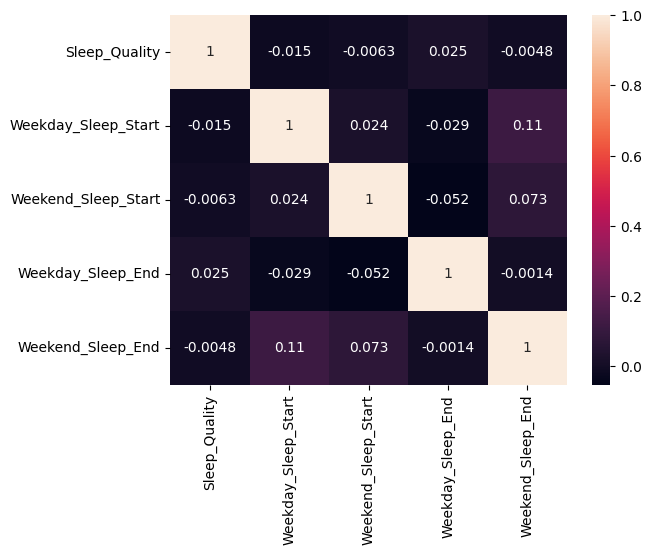

In [6]:
import seaborn as sns

sns.heatmap(data_time.corr(), annot=True)

In [8]:
data = pd.read_csv('student_sleep_patterns.csv')
data = data[data['Sleep_Quality']>=8]
data

,Student_ID,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Sleep_Quality,Weekday_Sleep_Start,Weekend_Sleep_Start,Weekday_Sleep_End,Weekend_Sleep_End
0,1,24,Other,2nd Year,7.7,7.9,3.4,2,37,10,14.16,4.05,7.41,7.06
3,4,24,Other,4th Year,6.3,8.6,2.8,4,55,9,19.82,4.08,6.69,9.42
5,6,25,Other,1st Year,4.9,12.0,3.2,3,96,9,9.80,18.83,5.04,10.51
9,10,19,Other,2nd Year,5.8,8.2,2.0,3,44,8,14.65,5.31,7.47,9.37
14,15,25,Female,4th Year,4.9,10.4,2.3,4,7,8,7.02,19.21,7.27,9.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,480,21,Female,3rd Year,8.0,2.2,2.9,0,6,8,3.87,4.42,7.70,7.76
482,483,22,Other,1st Year,4.4,7.9,2.5,3,84,9,5.42,14.57,7.87,8.83
488,489,18,Female,1st Year,6.6,3.5,1.8,3,46,10,21.33,17.98,8.46,10.17
493,494,23,Female,2nd Year,4.8,1.5,3.1,1,114,8,21.43,15.86,5.56,10.14


In [17]:
x = data.drop(columns=['Student_ID', 'Weekend_Sleep_Start', 'Weekend_Sleep_End', 'Weekday_Sleep_End'])
x

,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Sleep_Quality,Weekday_Sleep_Start
0,24,Other,2nd Year,7.7,7.9,3.4,2,37,10,14.16
3,24,Other,4th Year,6.3,8.6,2.8,4,55,9,19.82
5,25,Other,1st Year,4.9,12.0,3.2,3,96,9,9.80
9,19,Other,2nd Year,5.8,8.2,2.0,3,44,8,14.65
14,25,Female,4th Year,4.9,10.4,2.3,4,7,8,7.02
...,...,...,...,...,...,...,...,...,...,...
479,21,Female,3rd Year,8.0,2.2,2.9,0,6,8,3.87
482,22,Other,1st Year,4.4,7.9,2.5,3,84,9,5.42
488,18,Female,1st Year,6.6,3.5,1.8,3,46,10,21.33
493,23,Female,2nd Year,4.8,1.5,3.1,1,114,8,21.43


In [18]:
y = data[['Weekday_Sleep_End']]
y

,Weekday_Sleep_End
0,7.41
3,6.69
5,5.04
9,7.47
14,7.27
...,...
479,7.70
482,7.87
488,8.46
493,5.56


In [19]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
x['Gender'] = encoder.fit_transform(x['Gender'])
x

,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Sleep_Quality,Weekday_Sleep_Start
0,24,2,2nd Year,7.7,7.9,3.4,2,37,10,14.16
3,24,2,4th Year,6.3,8.6,2.8,4,55,9,19.82
5,25,2,1st Year,4.9,12.0,3.2,3,96,9,9.80
9,19,2,2nd Year,5.8,8.2,2.0,3,44,8,14.65
14,25,0,4th Year,4.9,10.4,2.3,4,7,8,7.02
...,...,...,...,...,...,...,...,...,...,...
479,21,0,3rd Year,8.0,2.2,2.9,0,6,8,3.87
482,22,2,1st Year,4.4,7.9,2.5,3,84,9,5.42
488,18,0,1st Year,6.6,3.5,1.8,3,46,10,21.33
493,23,0,2nd Year,4.8,1.5,3.1,1,114,8,21.43


In [20]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
x['University_Year'] = encoder.fit_transform(x['University_Year'])
x['University_Year'] = x['University_Year']+1
x

,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Sleep_Quality,Weekday_Sleep_Start
0,24,2,2,7.7,7.9,3.4,2,37,10,14.16
3,24,2,4,6.3,8.6,2.8,4,55,9,19.82
5,25,2,1,4.9,12.0,3.2,3,96,9,9.80
9,19,2,2,5.8,8.2,2.0,3,44,8,14.65
14,25,0,4,4.9,10.4,2.3,4,7,8,7.02
...,...,...,...,...,...,...,...,...,...,...
479,21,0,3,8.0,2.2,2.9,0,6,8,3.87
482,22,2,1,4.4,7.9,2.5,3,84,9,5.42
488,18,0,1,6.6,3.5,1.8,3,46,10,21.33
493,23,0,2,4.8,1.5,3.1,1,114,8,21.43


In [21]:
from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()
x1 = x_scaler.fit_transform(x)
x1 = pd.DataFrame(x1, columns=x.columns)
x1

,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Sleep_Quality,Weekday_Sleep_Start
0,0.857143,1.0,0.333333,0.734694,0.655462,0.800000,0.4,0.308333,1.0,0.628544
1,0.857143,1.0,1.000000,0.448980,0.714286,0.600000,0.8,0.458333,0.5,0.900529
2,1.000000,1.0,0.000000,0.163265,1.000000,0.733333,0.6,0.800000,0.5,0.419029
3,0.142857,1.0,0.333333,0.346939,0.680672,0.333333,0.6,0.366667,0.0,0.652090
4,1.000000,0.0,1.000000,0.163265,0.865546,0.433333,0.8,0.058333,0.0,0.285440
...,...,...,...,...,...,...,...,...,...,...
140,0.428571,0.0,0.666667,0.795918,0.176471,0.633333,0.0,0.050000,0.0,0.134070
141,0.571429,1.0,0.000000,0.061224,0.655462,0.500000,0.6,0.700000,0.5,0.208554
142,0.000000,0.0,0.000000,0.510204,0.285714,0.266667,0.6,0.383333,1.0,0.973090
143,0.714286,0.0,0.333333,0.142857,0.117647,0.700000,0.2,0.950000,0.0,0.977895


In [22]:
from sklearn.preprocessing import MinMaxScaler

y_scaler = MinMaxScaler()
y1 = y_scaler.fit_transform(y)
y1 = pd.DataFrame(y1, columns=y.columns)
y1

,Weekday_Sleep_End
0,0.610127
1,0.427848
2,0.010127
3,0.625316
4,0.574684
...,...
140,0.683544
141,0.726582
142,0.875949
143,0.141772


In [27]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size=0.2)

In [28]:
y_test

,Weekday_Sleep_End
40,0.579747
62,0.782278
113,0.756962
22,0.460759
126,0.283544
16,0.549367
109,0.032911
74,0.422785
61,0.602532
115,0.382278


In [29]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=10)

model.fit(x_train, y_train)

KNeighborsRegressor(n_neighbors=10)

In [30]:
y_pred = model.predict(x_test)
y_pred = pd.DataFrame(y_pred, index=y_test.index, columns=y_test.columns)
y_pred


,Weekday_Sleep_End
40,0.632405
62,0.753671
113,0.575443
22,0.508608
126,0.446076
16,0.519747
109,0.526582
74,0.601772
61,0.313924
115,0.267342


In [31]:
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test, y_pred))

0.2352335224792667


In [38]:
human = x1.iloc[[0], :]
human

,Age,Gender,University_Year,Sleep_Duration,Study_Hours,Screen_Time,Caffeine_Intake,Physical_Activity,Sleep_Quality,Weekday_Sleep_Start
0,0.857143,1.0,0.333333,0.734694,0.655462,0.8,0.4,0.308333,1.0,0.628544


In [36]:
optimal_sleep_end = model.predict(human)
optimal_sleep_end

array([[0.31924051]])

In [37]:
optimal_sleep_end = y_scaler.inverse_transform(optimal_sleep_end)
optimal_sleep_end

array([[6.261]])

In [39]:
print(6.261*(1-0.23))
print(6.261*(1+0.23))

4.82097
7.70103
